In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
df = pd.read_csv('data.csv', encoding='utf-8')
df.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year
0,Spain,La Liga,(BET),Juanmi Callejon,19,16,1849,11,6.62,0.34,48,20,2.47,1.03,2016
1,Spain,La Liga,(BAR),Antoine Griezmann,36,0,3129,16,11.86,0.36,88,41,2.67,1.24,2016
2,Spain,La Liga,(ATL),Luis Suarez,34,1,2940,28,23.21,0.75,120,57,3.88,1.84,2016
3,Spain,La Liga,(CAR),Ruben Castro,32,3,2842,13,14.06,0.47,117,42,3.91,1.40,2016
4,Spain,La Liga,(VAL),Kevin Gameiro,21,10,1745,13,10.65,0.58,50,23,2.72,1.25,2016


In [27]:
print(df.isnull().sum())

Country                     0
League                      0
Club                       34
Player Names                0
Matches_Played              0
Substitution                0
Mins                        0
Goals                       0
xG                          0
xG Per Avg Match            0
Shots                       0
OnTarget                    0
Shots Per Avg Match         0
On Target Per Avg Match     0
Year                        0
dtype: int64


In [28]:
missing_val = (df.isnull().sum()/len(df))*100
print(missing_val)

Country                    0.000000
League                     0.000000
Club                       5.151515
Player Names               0.000000
Matches_Played             0.000000
Substitution               0.000000
Mins                       0.000000
Goals                      0.000000
xG                         0.000000
xG Per Avg Match           0.000000
Shots                      0.000000
OnTarget                   0.000000
Shots Per Avg Match        0.000000
On Target Per Avg Match    0.000000
Year                       0.000000
dtype: float64


In [29]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [30]:
df["Club"] = df["Club"].fillna("Unknown")
print(df.isnull().sum())


Country                    0
League                     0
Club                       0
Player Names               0
Matches_Played             0
Substitution               0
Mins                       0
Goals                      0
xG                         0
xG Per Avg Match           0
Shots                      0
OnTarget                   0
Shots Per Avg Match        0
On Target Per Avg Match    0
Year                       0
dtype: int64


In [31]:
max_goals = df["Goals"].max()
max_player = df.loc[df["Goals"].idxmax(), "Player Names"]
print(f"Player name: {max_player}, Max goals: {max_goals}")

Player name: Lionel Messi, Max goals: 37


In [32]:
# player_name = input("Enter Player Name: ")

# # Search player in dataset
# player = df[df["Player Names"].str.lower() == player_name.lower()]

# # Check if player exists
# if not player.empty:
    
#     # Display required details
#     print("\nPlayer Details")
#     print("-------------------")
    
#     print("Player :", player.iloc[0]["Player Names"])
#     print("Goals  :", player.iloc[0]["Goals"])
#     print("Matches :", player.iloc[0]["Matches_Played"])
#     print("Shots  :", player.iloc[0]["Shots"])
    
# else:
#     print("Player not found in dataset")

In [33]:
df.dtypes
df.head()

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year
0,Spain,La Liga,(BET),Juanmi Callejon,19,16,1849,11,6.62,0.34,48,20,2.47,1.03,2016
1,Spain,La Liga,(BAR),Antoine Griezmann,36,0,3129,16,11.86,0.36,88,41,2.67,1.24,2016
2,Spain,La Liga,(ATL),Luis Suarez,34,1,2940,28,23.21,0.75,120,57,3.88,1.84,2016
3,Spain,La Liga,(CAR),Ruben Castro,32,3,2842,13,14.06,0.47,117,42,3.91,1.40,2016
4,Spain,La Liga,(VAL),Kevin Gameiro,21,10,1745,13,10.65,0.58,50,23,2.72,1.25,2016


In [34]:
df.columns = df.columns.str.strip()

In [35]:
from sklearn.preprocessing import StandardScaler

df.columns = df.columns.str.strip()
col = ['Matches_Played','Substitution','Mins','xG','Shots','OnTarget']
std_obj = StandardScaler()
df[col] = std_obj.fit_transform(df[col])
df

,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year
0,Spain,La Liga,(BET),Juanmi Callejon,-0.345862,3.329978,-0.247154,11,-0.606521,0.34,-0.463331,-0.511607,2.47,1.03,2016
1,Spain,La Liga,(BAR),Antoine Griezmann,1.398217,-0.840393,1.175207,16,0.309482,0.36,0.682304,0.772738,2.67,1.24,2016
2,Spain,La Liga,(ATL),Luis Suarez,1.193031,-0.579745,0.965186,28,2.293573,0.75,1.598811,1.751287,3.88,1.84,2016
3,Spain,La Liga,(CAR),Ruben Castro,0.987845,-0.058448,0.856287,13,0.694064,0.47,1.512889,0.833898,3.91,1.40,2016
4,Spain,La Liga,(VAL),Kevin Gameiro,-0.140677,1.766089,-0.362720,13,0.097962,0.58,-0.406049,-0.328129,2.72,1.25,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,Netherlands,Eredivisie,(UTR),Gyrano Kerk,0.167102,-0.840393,0.092879,10,-0.454436,0.33,-0.406049,-0.633925,2.20,0.79,2020
656,Netherlands,Eredivisie,(AJA),Quincy Promes,-0.448455,-0.319097,-0.553850,12,-0.055870,0.59,-0.234204,0.099986,3.38,1.81,2020
657,Netherlands,Eredivisie,(PSV),Denzel Dumfries,0.269695,-0.840393,0.324013,7,-0.763850,0.23,-0.549254,-0.878562,1.81,0.56,2020
658,Netherlands,Eredivisie,Unknown,Cyriel Dessers,0.372288,-0.840393,0.432912,15,0.772728,0.56,0.567740,0.895057,3.24,1.66,2020


In [36]:
features = [
    'Matches_Played',
    'Substitution',
    'Mins',
    'xG Per Avg Match',
    'Shots',
    'OnTarget',
    'Shots Per Avg Match',
    'On Target Per Avg Match'
]

In [37]:
target = ['Goals']

In [38]:
X = df[features]
y = df[target]

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
    y,
    test_size=0.2,
    random_state=42)
print(X_train.shape)
print(X_test.shape)




(528, 8)
(132, 8)


In [40]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [41]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Train model
model = XGBRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("Accuracy:", r2 * 100)

R2 Score: 0.8162325620651245
MAE: 1.8017691373825073
MSE: 5.402914524078369
RMSE: 2.3244170288651667
Accuracy: 81.62325620651245


In [42]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual_Goals': y_test.values.ravel(),
    'Predicted_Goals': predictions.ravel()
})

print(comparison.head())



   Actual_Goals  Predicted_Goals
0             6         9.178986
1             9         6.830391
2            29        26.508970
3             4         3.231805
4             9        12.137509


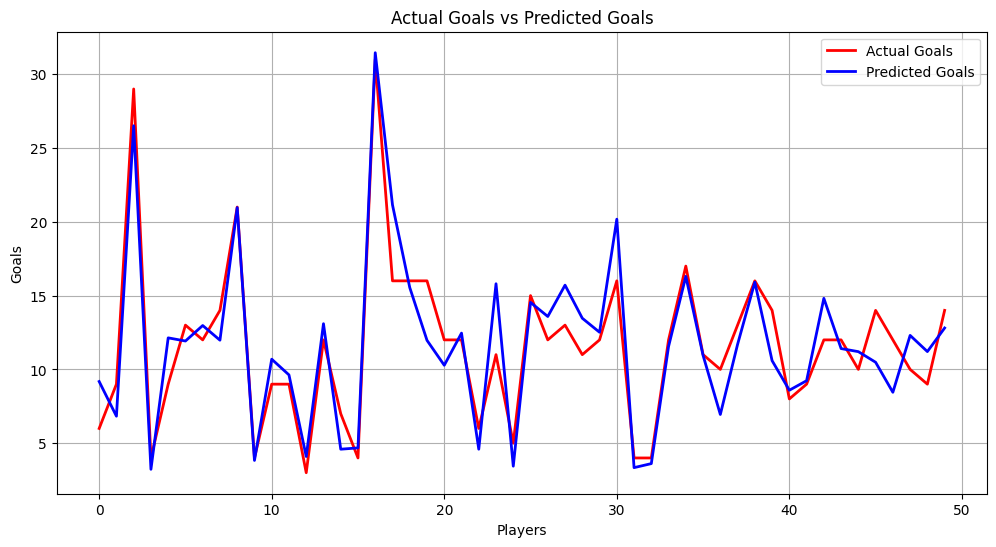

In [43]:
# Convert to 1D arrays
y_test_flat = np.ravel(y_test)
predictions_flat = np.ravel(y_pred)

plt.figure(figsize=(12,6))

# Actual goals → Red
plt.plot(
    y_test_flat[:50],
    color='red',
    label='Actual Goals',
    linewidth=2
)

# Predicted goals → Blue
plt.plot(
    predictions_flat[:50],
    color='blue',
    label='Predicted Goals',
    linewidth=2
)

plt.xlabel("Players")
plt.ylabel("Goals")

plt.title("Actual Goals vs Predicted Goals")

plt.legend()

plt.grid(True)

plt.show()

In [44]:
import pickle

# Save trained model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)